**Objective**

The goal of this notebook is to build and evaluate regression-based models
to forecast monthly sales using engineered time-series features such as
lag variables, rolling statistics, and calendar attributes.


**Load Data**

In [20]:
import pandas as pd

df=pd.read_csv("../data/monthly_sales_features.csv",parse_dates=["Order Date"])
df.set_index("Order Date",inplace=True)
df.head()

,Sales,month,year,lag_1,lag_2,lag_3,rolling_mean_3,rolling_mean_6
Order Date,,,,,,,,
2014-07-31,33946.3930,7,2014,34595.1276,28295.3450,14236.895,28846.253200,26831.092600
2014-08-31,27909.4685,8,2014,33946.3930,23648.2870,4519.892,30729.935867,30116.008933
2014-09-30,81777.3508,9,2014,27909.4685,34595.1276,55691.009,32150.329700,34014.271683
2014-10-31,31453.3930,10,2014,81777.3508,33946.3930,28295.345,47877.737433,38361.995317
2014-11-30,78628.7167,11,2014,31453.3930,27909.4685,23648.287,47046.737433,38888.336650


In [21]:
type(df.index)


pandas.core.indexes.datetimes.DatetimeIndex

**Defining Features(X) and Target(y)**

In [22]:
X=df.drop("Sales",axis=1)
y=df["Sales"]

- Target variable: Monthly Sales
- Features: Lag values, rolling means, and calendar features


**Time-Aware Train–Test Split**

In [23]:
split_date="2017-01-01"

X_train=X[X.index < split_date]
X_test=X[X.index >= split_date]

y_train=y[y.index < split_date]
y_test=y[y.index >= split_date]

The data is split chronologically to prevent data leakage from future observations.


**Baseline Model: Linear Regression**

In [24]:
from sklearn.linear_model import LinearRegression

lr=LinearRegression()
lr.fit(X_train,y_train)

y_pred_lr=lr.predict(X_test)

**Model Evaluation**

In [25]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np  

mae_lr=mean_absolute_error(y_test,y_pred_lr)
rmse_lr=np.sqrt(mean_squared_error(y_test,y_pred_lr))

print(f"Linear Regression MAE: {mae_lr}")
print(f"Linear Regression RMSE: {rmse_lr}")

Linear Regression MAE: 14984.762883573616
Linear Regression RMSE: 17849.945838929067


- Lower RMSE indicates better forecasting accuracy.
- This model serves as a baseline for future comparisons.


**Actual Vs Predicted**

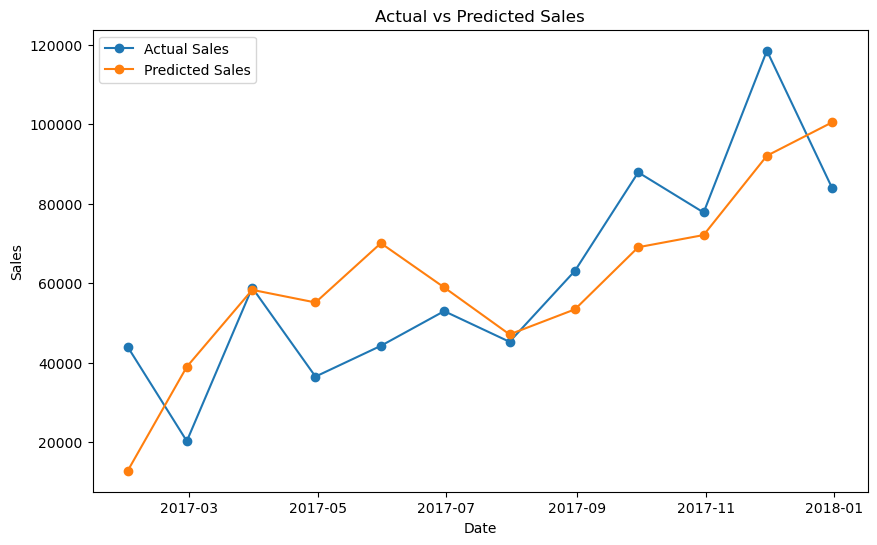

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.plot(y_test.index, y_test, label='Actual Sales', marker='o')
plt.plot(y_test.index, y_pred_lr, label='Predicted Sales', marker='o')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.title('Actual vs Predicted Sales')
plt.legend()
plt.show()

**Feature Importance**

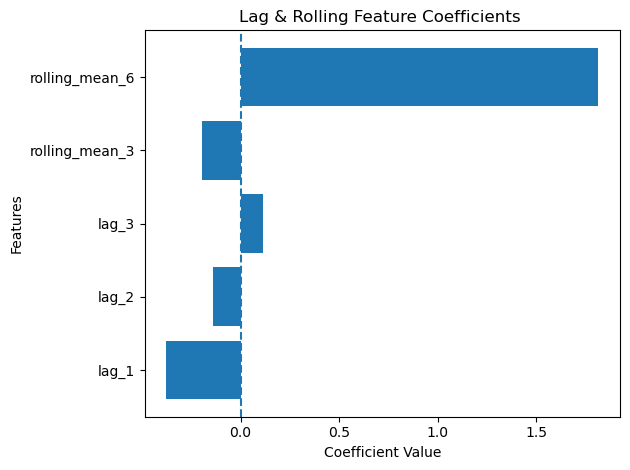

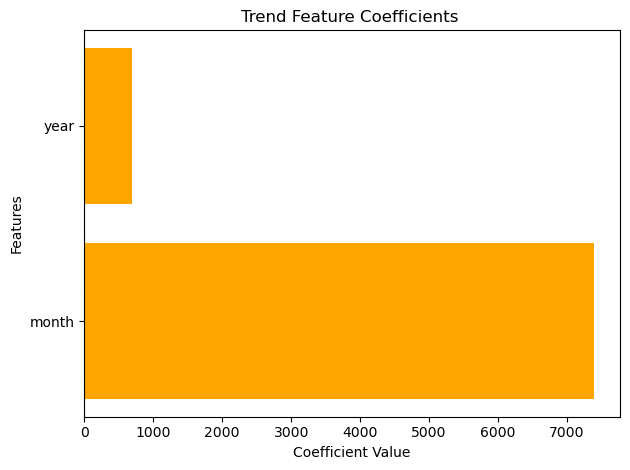

In [47]:
coefficients = pd.Series(lr.coef_, index=X_train.columns)

lag_features=coefficients.drop(['month','year'])
plt.barh(lag_features.index, lag_features.values)
plt.title('Lag & Rolling Feature Coefficients ')
plt.xlabel('Coefficient Value')
plt.ylabel('Features')
plt.axvline(0,linestyle='--')
plt.tight_layout()
plt.show()


trend_features=coefficients[['month','year']]
plt.barh(trend_features.index, trend_features.values, color='orange')
plt.title('Trend Feature Coefficients ')
plt.xlabel('Coefficient Value')
plt.ylabel('Features')
plt.axvline(0,linestyle='--')
plt.tight_layout()
plt.show()


**Random Forest Model**

In [49]:
from sklearn.ensemble import RandomForestRegressor

rf=RandomForestRegressor(n_estimators=100,random_state=42)
rf.fit(X_train,y_train)

y_pred_rf=rf.predict(X_test)
mae_rf=mean_absolute_error(y_test,y_pred_rf)
rmse_rf=np.sqrt(mean_squared_error(y_test,y_pred_rf))
print(f"Random Forest MAE: {mae_rf}")
print(f"Random Forest RMSE: {rmse_rf}")

Random Forest MAE: 14419.355863166675
Random Forest RMSE: 17882.676906981957


**Actual vs Predicted (Random-Forest)**

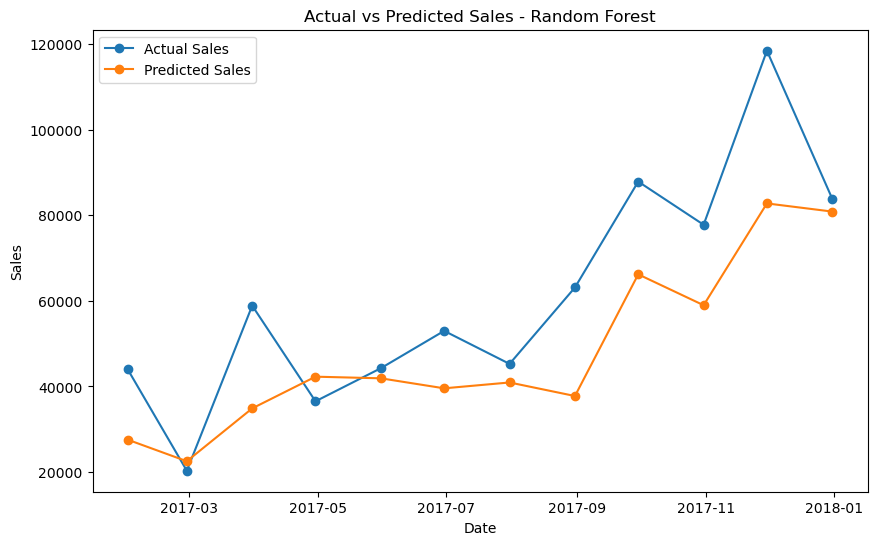

In [50]:
plt.figure(figsize=(10,6))
plt.plot(y_test.index, y_test, label='Actual Sales', marker='o')
plt.plot(y_test.index, y_pred_rf, label='Predicted Sales', marker='o')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.title('Actual vs Predicted Sales - Random Forest')
plt.legend()

**Model Comparison Random Forest Vs Linerar Regression**

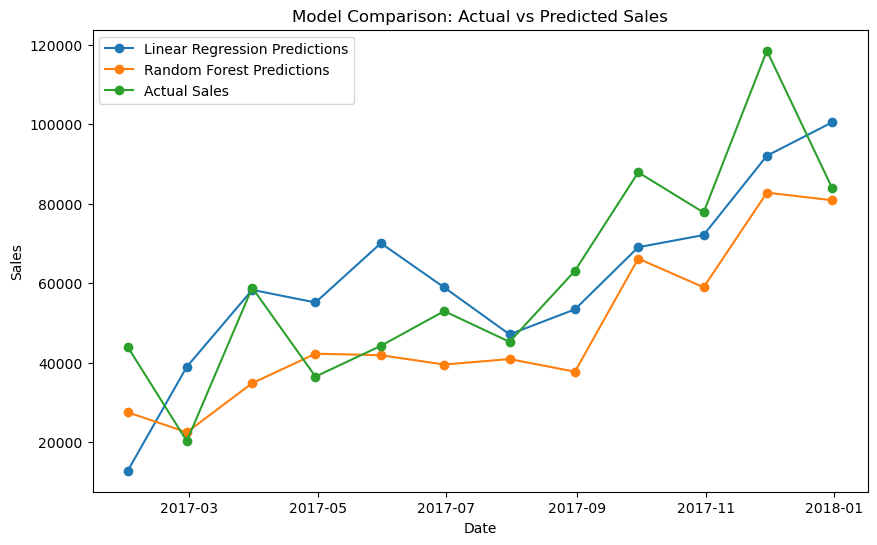

In [51]:
plt.figure(figsize=(10,6))
plt.plot(y_test.index,y_pred_lr,label='Linear Regression Predictions',marker='o')
plt.plot(y_test.index,y_pred_rf,label='Random Forest Predictions',marker='o')
plt.plot(y_test.index,y_test,label='Actual Sales',marker='o')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.title('Model Comparison: Actual vs Predicted Sales')
plt.legend()
plt.show()

## Final Insights and Conclusions

**Model Comparison Insight**
- Two models were evaluated: Linear Regression and Random Forest Regression. Linear Regression demonstrated stronger performance in capturing the overall sales trend and seasonal fluctuations. Random Forest predictions were smoother and tended to underpredict during periods of sharp sales increases, indicating limited extrapolation ability for time-dependent trends.

**Why Linear Regression works well here**
- The dataset exhibits a strong temporal trend and seasonality. Linear Regression benefits from explicitly engineered time-based features such as lag variables and rolling averages, allowing it to model both short-term dependencies and long-term growth effectively.

**Business Interpretation**
- For sales forecasting and trend analysis, capturing direction and magnitude of change is critical. Linear Regression provides more reliable forecasts during growth periods, making it better suited for strategic planning and demand forecasting in this context.

**Conclusion**
- **Linear Regression** is selected as the final model due to its superior trend capture, interpretability, and consistent performance across time.